In [3]:
import sys, os

import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
root = Path.cwd().parents[1]
sys.path.extend([str(root), str(root / 'plotting')])

from im_net import datamanager, plotting
import datareader

%load_ext autoreload
%autoreload 2

In [2]:
plot_path = "../figures/appendix/finite_size"

plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})
plt.rcParams['svg.fonttype'] = 'none'

n_colors = 3
colormap_seq = [plt.cm.Blues(0.4 + (1 - 0.4) * x / n_colors) for x in range(n_colors)]

alpha_h   = 0.14
alpha_red = 1.59

## Data Loading — Redundancy Profile (Panel A)

Redundancy $\Pi_{\mathrm{red}}$ averaged over neurons as a function of memory load,
for three network sizes. Networks are initialised with Hebbian weights and evaluated
at epoch 0 (no infomorphic training).

**Training command:**
```bash
python src/training.py storage=cluster params.pref_gpu=False \
    params.seed='range(20)' params.alpha='range(0.01,2.01,0.05)' \
    binning=adaptive model=hebbian_start params.epochs=0 \
    storage.final.pid=True params.neurons=100,200,500
```

In [ ]:
def get_pid_profile(file):
    """Load PID atoms as (5, n_alpha, n_seeds, n_neurons) array."""
    dm = datamanager.DataManager(file, mode='analysis', add_run_properties=True, verbose=0)
    datareader.sort_dm(dm, 'params.alpha')
    n_reps    = len(set(dm.sel['params.seed']))
    n_neurons = dm.sel['params.neurons'][0]
    pid_final = datareader.pid_to_numpy(dm, mean=False)
    return pid_final.reshape(5, -1, n_reps, n_neurons)


# TODO: set paths to PID profile experiment folders
file_pid_100 = ''
file_pid_200 = ''
file_pid_500 = ''

pid_100 = get_pid_profile(file_pid_100)
pid_200 = get_pid_profile(file_pid_200)
pid_500 = get_pid_profile(file_pid_500)

# Mean redundancy over neurons per seed; shape (n_alpha, n_seeds)
redundancy_100 = np.mean(pid_100[datareader.REDUNDANCY], axis=2)
redundancy_200 = np.mean(pid_200[datareader.REDUNDANCY], axis=2)
redundancy_500 = np.mean(pid_500[datareader.REDUNDANCY], axis=2)

x_alpha = np.arange(0.01, 2.01, 0.05)
print(f"Redundancy shapes: {redundancy_100.shape}, {redundancy_200.shape}, {redundancy_500.shape}")

Redundancy shapes: (40, 20), (40, 20), (40, 20)


## Data Loading — Recall Accuracy (Panel B)

Recall accuracy as a function of memory load in the low-$\alpha$ regime,
for three network sizes.

**Training command:**
```bash
python src/training.py -m storage=cluster params.pref_gpu=False \
    params.epochs=5000 params.seed='range(20)' \
    +mods/capacity=paper capacity.stop=0.42 params.neurons=100,200,500
```

In [ ]:
# TODO: set path to finite-size recall accuracy run
red_file = ''

dm_acc, x_vals, acc_raw, neuron_labels = datareader.load_capacity_runs(red_file, 'params.neurons')

n_reps   = len(set(dm_acc.sel['params.seed']))
alpha_acc = x_vals[0]
acc       = acc_raw.reshape((-1, n_reps, acc_raw.shape[-1]))  # (n_neurons, n_seeds, n_alpha)
neurons_acc = neuron_labels[::n_reps].values

print(f"Alpha values: {alpha_acc}")
print(f"N values: {neurons_acc}, acc shape: {acc.shape}")

Alpha values: [0.01 0.06 0.11 0.16 0.21 0.26 0.31 0.36 0.41]
N values: [100 200 500], acc shape: (3, 20, 9)


## Panel A: Redundancy Profile

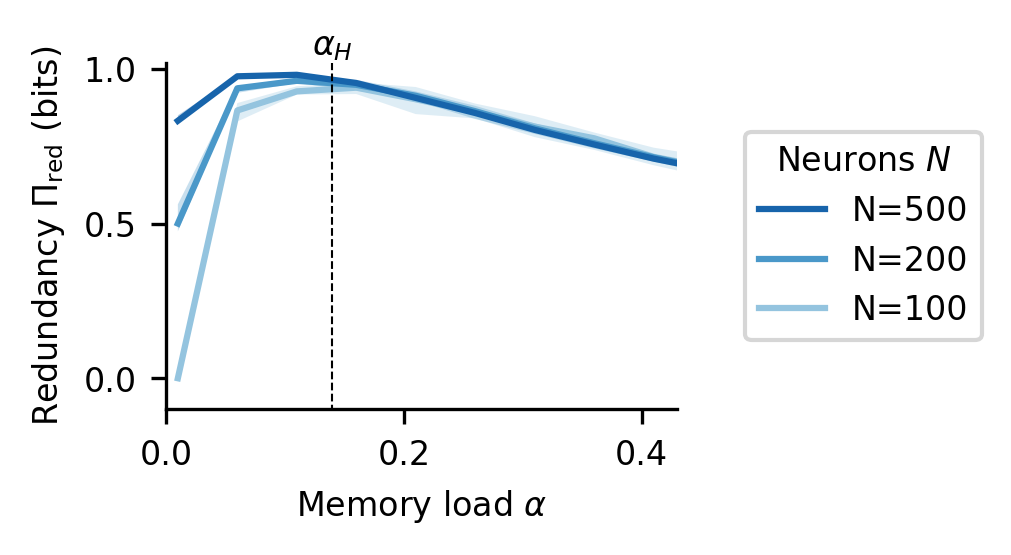

In [5]:
fig, ax = plt.subplots(1)
ax.set_prop_cycle(color=colormap_seq)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Redundancy $\Pi_{\mathrm{red}}$ (bits)')

plotting.plot_mean_and_area(ax, x_alpha, redundancy_100, mean_ax=1, quantile=0.9, label='N=100', median=True)
plotting.plot_mean_and_area(ax, x_alpha, redundancy_200, mean_ax=1, quantile=0.9, label='N=200', median=True)
plotting.plot_mean_and_area(ax, x_alpha, redundancy_500, mean_ax=1, quantile=0.9, label='N=500', median=True)

ax.vlines(alpha_h, -1, 2, 'k', '--', linewidth=0.5)
ax.text(alpha_h, 1 + 0.02, r'$\alpha_H$', ha='center', va='bottom')

plotting.layout_performance(ax, x_lim=(0, 0.4), y_lim=(0, 1), x_log=False, show_legend=False,
                            border_x=(0, 0.03), border_y=(0.1, 0.02))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), title='Neurons $N$',
          loc='center left', bbox_to_anchor=(1.1, 0.5))
plotting.standard_look(ax, ticks=False)
# fig.savefig(f"{plot_path}/pid_scaling.svg", bbox_inches='tight')
plt.show()

## Panel B: Recall Accuracy

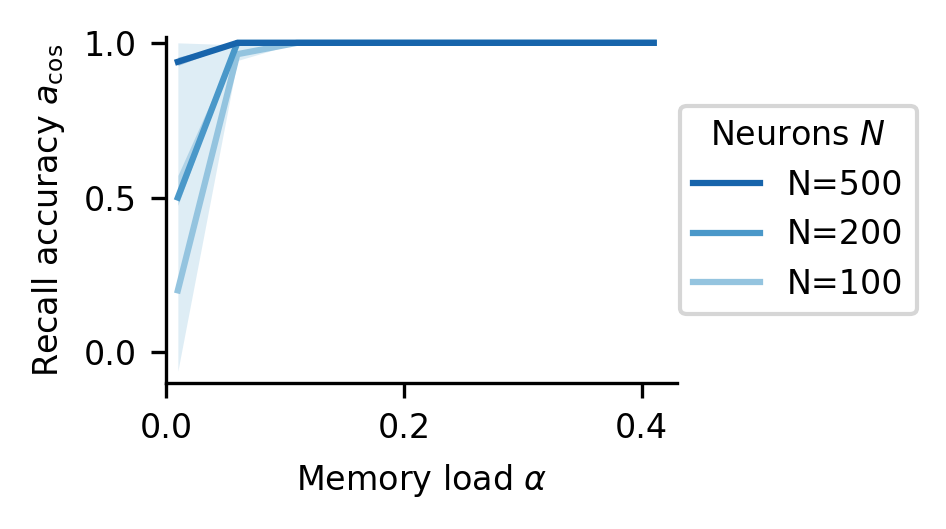

In [6]:
fig, ax = plt.subplots(1)
ax.set_prop_cycle(color=colormap_seq)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Recall accuracy $a_{\mathrm{cos}}$')

for x, N in zip(acc, neurons_acc):
    plotting.plot_mean_and_area(ax, alpha_acc, x, label=f'N={N}', quantile=0.9, median=True, mean_ax=0)

plotting.layout_performance(ax, (0, 0.4), x_log=False, show_legend=False,
                            border_x=(0, 0.03), border_y=(0.1, 0.02))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), title='Neurons $N$',
          loc='center right', bbox_to_anchor=(1.5, 0.5))
plotting.standard_look(ax, ticks=False)
# fig.savefig(f"{plot_path}/capacity_scaling.svg", bbox_inches='tight')
plt.show()

## Combined Figure (Panels A + B)

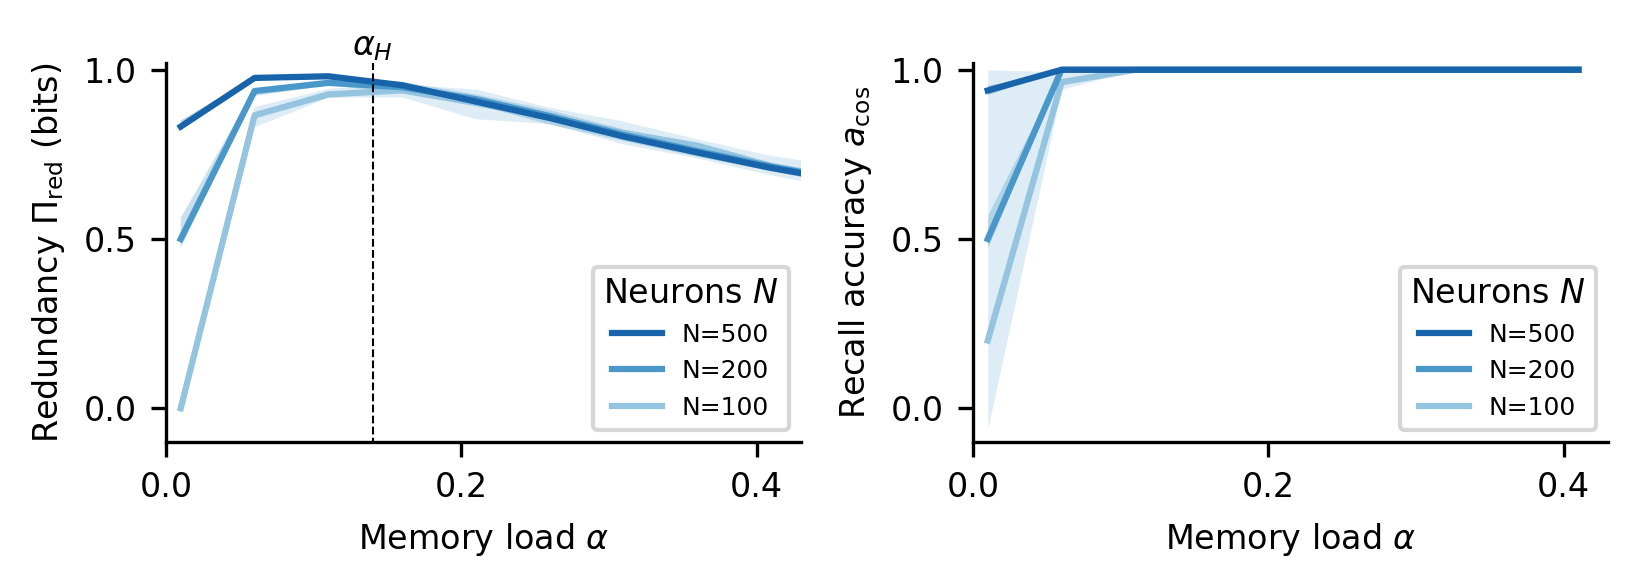

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2), dpi=300)
ax_a, ax_b = axes

# ── Panel A ─────────────────────────────────────────────────────────────────
ax_a.set_prop_cycle(color=colormap_seq)
ax_a.set_xlabel(r'Memory load $\alpha$')
ax_a.set_ylabel(r'Redundancy $\Pi_{\mathrm{red}}$ (bits)')

plotting.plot_mean_and_area(ax_a, x_alpha, redundancy_100, mean_ax=1, quantile=0.9, label='N=100', median=True)
plotting.plot_mean_and_area(ax_a, x_alpha, redundancy_200, mean_ax=1, quantile=0.9, label='N=200', median=True)
plotting.plot_mean_and_area(ax_a, x_alpha, redundancy_500, mean_ax=1, quantile=0.9, label='N=500', median=True)

ax_a.vlines(alpha_h, -1, 2, 'k', '--', linewidth=0.5)
ax_a.text(alpha_h, 1 + 0.02, r'$\alpha_H$', ha='center', va='bottom')

plotting.layout_performance(ax_a, x_lim=(0, 0.4), y_lim=(0, 1), x_log=False, show_legend=False,
                            border_x=(0, 0.03), border_y=(0.1, 0.02))
handles, labels = ax_a.get_legend_handles_labels()
ax_a.legend(reversed(handles), reversed(labels), title='Neurons $N$',
            loc='lower right', fontsize=6)
plotting.standard_look(ax_a, ticks=False)

# ── Panel B ─────────────────────────────────────────────────────────────────
ax_b.set_prop_cycle(color=colormap_seq)
ax_b.set_xlabel(r'Memory load $\alpha$')
ax_b.set_ylabel(r'Recall accuracy $a_{\mathrm{cos}}$')

for x, N in zip(acc, neurons_acc):
    plotting.plot_mean_and_area(ax_b, alpha_acc, x, label=f'N={N}', quantile=0.9, median=True, mean_ax=0)

plotting.layout_performance(ax_b, (0, 0.4), x_log=False, show_legend=False,
                            border_x=(0, 0.03), border_y=(0.1, 0.02))
handles, labels = ax_b.get_legend_handles_labels()
ax_b.legend(reversed(handles), reversed(labels), title='Neurons $N$',
            loc='lower right', fontsize=6)
plotting.standard_look(ax_b, ticks=False)

# fig.savefig(f"{plot_path}/finite_size_combined.svg", bbox_inches='tight')
fig.tight_layout()
plt.show()